In [1]:
import os
import re
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.append("/home/sam/Halo_Finder/Final_design/base_script")
from config_io import load_multifield_from_disk
from experiment import build_bg_only_cfg
from bg_stage import run_bg_inference, train_bg_only


def _global_diag(x_true, x_hat):
    """Global reconstruction metrics (replaces the old ROI diagnostics)."""
    x_true = np.asarray(x_true); x_hat = np.asarray(x_hat)
    dr = float(x_true.max() - x_true.min()) or 1.0
    mse = float(np.mean((x_true - x_hat) ** 2))
    psnr = 20 * np.log10(dr) - 10 * np.log10(mse + 1e-12) if mse > 0 else 100.0
    max_err = float(np.max(np.abs(x_true - x_hat)))
    return {"psnr": psnr, "max_err": max_err}

pysz_path = r"/home/sam/Data_Compression/SZ3/tools/pysz"
if pysz_path not in sys.path:
    sys.path.append(pysz_path)
from pysz import SZ


def set_seed(seed=17):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)



device: cuda


In [2]:
# ==== 路径与数据（可按需改 TARGET_STEM / REL_SETTINGS）====
import sys
from pathlib import Path

base_path = Path(r"/home/sam/Halo_Finder/halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin").resolve()
base_path = base_path.as_posix() + "/"
sz_lib_path = r"/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so"
data_shape = (512, 512, 512)

TARGET_STEM = "dark_matter_density"
FIELD_FILES = [
    "dark_matter_density.f32",
    "velocity_z.f32",
    "baryon_density.f32",
    "temperature.f32",
    "velocity_x.f32",
    "velocity_y.f32",
]

REL_SETTINGS = [("r0", 1e-4), ("r1", 2e-4), ("r2", 3e-4),("r3", 4e-4),("r4", 5e-4),("r5", 6e-4),("r6", 1e-5)]
REL_ACTIVE_IDX = 0
REL_ERR_SZ_BITSTREAM = REL_SETTINGS[REL_ACTIVE_IDX][1]


def rel_sz_suffix(rel_err: float) -> str:
    return f"{rel_err:.0e}".replace("+", "")


def sz_bin_for_target(fname: str, rel_err: float) -> str:
    stem = Path(fname).stem
    return base_path + stem + "_rel" + rel_sz_suffix(rel_err) + ".sz"

fname = TARGET_STEM + ".f32"
gt_path = base_path + fname
aux_paths = [base_path + f for f in FIELD_FILES if f != fname]
sz_bin_path = sz_bin_for_target(fname, REL_ERR_SZ_BITSTREAM)

_sz_path = Path(sz_bin_path)
if not _sz_path.is_file():
    from pysz import SZ
    print("[save .sz] 压缩:", _sz_path)
    eng = SZ(sz_lib_path)
    vol = np.fromfile(gt_path, dtype=np.float32).reshape(data_shape)
    blob, cr = eng.compress(vol, 1, 0, REL_ERR_SZ_BITSTREAM, 0)
    del vol
    _sz_path.parent.mkdir(parents=True, exist_ok=True)
    _sz_path.write_bytes(blob)
    print("CR ≈", float(cr))

Xs, Xps = load_multifield_from_disk(
    gt_path=gt_path,
    aux_paths=aux_paths,
    sz_bin_path=sz_bin_path,
    data_shape=data_shape,
    pysz_path=pysz_path,
    sz_lib_path=sz_lib_path,
)
print("Loaded", TARGET_STEM, "| fields", len(Xs))

# (ROI removed -- global metrics only)

sz = SZ(sz_lib_path)
gt_target = np.asarray(Xs[0], np.float32)
aux_fields = [np.asarray(f, np.float32) for f in Xs[1:]]


def build_Xps_for_rel(rel_err: float):
    b, cr = sz.compress(gt_target, 1, 0, float(rel_err), 0)
    x_lq = sz.decompress(b, gt_target.shape, np.float32)
    return [x_lq] + aux_fields, float(cr), b

print("sanity CR:", build_Xps_for_rel(REL_SETTINGS[0][1])[1])



Loaded dark_matter_density | fields 6
sanity CR: 77.58107791952374


In [3]:
# ── NeurLZ baseline (LIVE) — SZ3 + monai BasicUNet, trained in-notebook ───────
# Replaces the CSV loader: per rel, train NeurLZ's BasicUNet on the SZ3 recon and
# append a results_compare entry with correct PSNR + CR (CR uses the entry's real
# sz3_bytes + the model's params, same as the BG curves). BasicUNet is auto-sized
# to ~the BG model's params (iso-parameter). Set ADD_NEURLZ=False to skip.
import io, contextlib
from monai.networks.nets import BasicUNet
from config_io import _error_bounded_post_process
from experiment import estimate_bg_model_param_bytes

ADD_NEURLZ        = True
NEURLZ_LR         = 1e-2
NEURLZ_BATCH      = 10
NEURLZ_MAX_PIXELS_PER_BATCH = 1024 * 1024   # cap batch*H*W so big slices don't OOM
NEURLZ_EPOCHS     = 100
NEURLZ_EVAL_EVERY = 4        # compute PSNR every K epochs (loss prints every epoch)
NEURLZ_VERBOSE    = True
NEURLZ_FEATURES   = "match"  # "match" -> auto-size to the BG model's params; or a 6-tuple

_aux_nlz = globals().get("aux_fields", [])
_nf_nlz  = 1 + len(_aux_nlz)
_bg_h_nlz = int(globals().get("DEFAULT_BG_H", 7))
_bg_params_nlz, _ = estimate_bg_model_param_bytes(
    n_fields=_nf_nlz, shape=data_shape, bg_arch="spatial", bg_h=_bg_h_nlz)

def _bu_nparams(features):
    with contextlib.redirect_stdout(io.StringIO()):
        m = BasicUNet(spatial_dims=2, features=tuple(features), act="gelu",
                      in_channels=_nf_nlz, out_channels=1)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad); del m
    return n

def _neurlz_features(target):
    if NEURLZ_FEATURES != "match":
        return tuple(NEURLZ_FEATURES)
    a, b, best = 4, 384, 4
    while a <= b:
        mid = (a + b) // 2
        if _bu_nparams((mid,) * 6) <= target: best = mid; a = mid + 1
        else: b = mid - 1
    hi = min(best + 1, 384)
    w = best if abs(_bu_nparams((best,)*6) - target) <= abs(_bu_nparams((hi,)*6) - target) else hi
    return (w,) * 6

def _mm_nlz(x, eps=1e-8):
    lo, hi = float(np.min(x)), float(np.max(x))
    return ((np.asarray(x, np.float32) - lo) / (hi - lo + eps)).astype(np.float32), (lo, hi)

NEURLZ_FEAT = _neurlz_features(_bg_params_nlz)
print(f"[neurlz] BasicUNet features={NEURLZ_FEAT} (~{_bu_nparams(NEURLZ_FEAT):,} params) "
      f"~ BG model {_bg_params_nlz:,} | n_fields={_nf_nlz}")

def run_neurlz_live(rel_err, tag):
    Xps_rel, sz_ratio, sz_bytes = build_Xps_for_rel(float(rel_err))
    lq  = np.ascontiguousarray(Xps_rel[0], np.float32)
    tgt = np.asarray(gt_target, np.float32)
    fields = [lq] + [np.asarray(a, np.float32) for a in Xps_rel[1:]]
    D, H, W = tgt.shape
    drange = float(tgt.max() - tgt.min())
    lq_n = np.stack([_mm_nlz(f)[0] for f in fields], axis=1)
    err_n, (e_lo, e_hi) = _mm_nlz(tgt - lq)
    ph, pw = (-H) % 16, (-W) % 16
    pad = ((0, 0), (0, 0), (0, ph), (0, pw))
    Xlq = torch.from_numpy(np.pad(lq_n, pad, mode="reflect"))
    Yer = torch.from_numpy(np.pad(err_n[:, None], pad, mode="reflect"))
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    eff = max(1, min(NEURLZ_BATCH, NEURLZ_MAX_PIXELS_PER_BATCH // (H * W)))

    set_seed(17)
    with contextlib.redirect_stdout(io.StringIO()):
        model = BasicUNet(spatial_dims=2, features=tuple(NEURLZ_FEAT), act="gelu",
                          in_channels=len(fields), out_channels=1).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=NEURLZ_LR)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=1500)
    mse = torch.nn.MSELoss()
    idx = np.arange(D)

    def _psnr_now():
        model.eval(); out = lq.copy()
        with torch.no_grad():
            for st in range(0, D, eff):
                bi = list(range(st, min(st + eff, D)))
                pr = model(Xlq[bi].to(device)).cpu().numpy()[:, 0, :H, :W]
                out[bi] = lq[bi] + (pr * (e_hi - e_lo + 1e-8) + e_lo)
        model.train()
        out = _error_bounded_post_process(x_enhanced=out, x_prime=lq, absolute_error_bound=0.0,
                                          relative_error_bound=float(rel_err), verbose=False, a=1.0)
        return _global_diag(tgt, out)["psnr"]

    hist = {"epoch": [], "loss": [], "psnr": [], "time": []}
    metric_log = []
    model.train()
    for ep in range(NEURLZ_EPOCHS):
        np.random.shuffle(idx); tot = nb = 0
        for st in range(0, D, eff):
            bi = idx[st:st + eff]
            loss = mse(model(Xlq[bi].to(device)), Yer[bi].to(device))
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step(); sch.step()
            tot += float(loss.item()); nb += 1
        avg = tot / max(nb, 1)
        hist["epoch"].append(ep + 1); hist["loss"].append(avg); hist["time"].append(float("nan"))
        if (ep + 1) % NEURLZ_EVAL_EVERY == 0 or ep == NEURLZ_EPOCHS - 1:
            p = _psnr_now(); hist["psnr"].append((ep + 1, p)); metric_log.append({"psnr": p, "epoch": ep + 1})
            if NEURLZ_VERBOSE:
                print(f"  [neurlz {tag} rel={rel_err:.0e}] ep {ep+1:3d}/{NEURLZ_EPOCHS} | MSE {avg:.6f} | PSNR {p:.2f} dB")
        elif NEURLZ_VERBOSE:
            print(f"  [neurlz {tag} rel={rel_err:.0e}] ep {ep+1:3d}/{NEURLZ_EPOCHS} | MSE {avg:.6f}")

    model_cpu = model.to("cpu"); del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return {
        "name": f"NeurLZ [{TARGET_STEM}] rel={tag} [live]",
        "cfg": {"bg_arch": "neurlz_basicunet_live", "field": TARGET_STEM, "rel_err": float(rel_err)},
        "hist": hist, "metric_log": metric_log, "model": model_cpu,
        "rel_err": float(rel_err), "sz_ratio": float(sz_ratio),
        "sz3_bytes": int(len(sz_bytes)), "ablation_panel": None,
        "color": "tab:cyan", "marker": "X", "x_hat": None,
    }

if "results_compare" not in globals():
    results_compare = []
if ADD_NEURLZ:
    results_compare = [r for r in results_compare if "NeurLZ" not in str(r.get("name", ""))]  # drop stale NeurLZ
    for tag, rel in REL_SETTINGS:
        results_compare.append(run_neurlz_live(rel, tag))
print("NeurLZ live entries:", sum(1 for r in results_compare if "NeurLZ" in str(r.get("name", ""))))


NeurLZ CSV entries: 7


In [4]:
import time
import re
from pathlib import Path

set_seed(17)

# 每次 train_bg_variant 结束后保存 checkpoint；改为 None 可关闭落盘
BG_CKPT_ROOT = Path("/home/sam/Halo_Finder/halo_finder_v1/scripts/ablation_ckpts")

BG_TRAIN_TIME = 60.0
BG_LR = 1e-3
BG_PATCH = 512
BG_BATCH = 1
MODEL_DTYPE_BYTES = 2

DEFAULT_BG_ARCH = "spatial"
DEFAULT_BG_H = 7
DEFAULT_BG_FIELD_NORM = "zscore"
DEFAULT_BG_FREQ_WEIGHT = 1
DEFAULT_BG_FFT_PHASE_WEIGHT = 1
DEFAULT_BG_FREQ_WARMUP = 1
DEFAULT_BG_SPLIT_MODE = "three"


def model_param_bytes(model, dtype_bytes=None):
    if model is None:
        return 0
    tot = 0
    for p in model.parameters():
        tot += p.numel() * (p.element_size() if dtype_bytes is None else int(dtype_bytes))
    return int(tot)


def psnr_np(x_true, x_hat):
    x_true = np.asarray(x_true, dtype=np.float64)
    x_hat = np.asarray(x_hat, dtype=np.float64)
    mse = float(np.mean((x_true - x_hat) ** 2))
    dr = float(np.max(x_true) - np.min(x_true))
    if mse <= 0:
        return float("inf")
    return float(20.0 * np.log10(max(dr, 1e-12) / np.sqrt(mse)))


def get_run_psnr(r, mode="best"):
    logs = r.get("metric_log", []) or []
    vals = [float(m["psnr"]) for m in logs if m.get("psnr") is not None and np.isfinite(float(m["psnr"]))]
    if vals:
        return float(max(vals) if mode == "best" else vals[-1])
    if r.get("x_hat") is not None:
        return psnr_np(Xs[0], r["x_hat"])
    return float("nan")


def patch_sz3_bytes(r):
    rel = float(r.get("rel_err", float("nan")))
    if not np.isfinite(rel):
        return
    sb = r.get("sz3_bytes", None)
    if sb is None or sb <= 0:
        _, _, b = build_Xps_for_rel(rel)
        r["sz3_bytes"] = int(len(b))
        r["sz_ratio"] = float(gt_target.nbytes / max(len(b), 1))


def _ablation_ckpt_slug(s, max_len=72):
    t = str(s).strip().replace(" ", "_")
    t = re.sub(r"[^\w.\-]+", "_", t)
    return t[:max_len] or "run"

def purge_ablation_panel(panel: str) -> None:
    global results_compare
    results_compare = [r for r in results_compare if r.get("ablation_panel") != panel]

# 例：purge_ablation_panel("norm")

def train_bg_variant(
    tag,
    rel_err,
    *,
    name,
    ablation_panel,
    ablation_tag,
    bg_field_norm=DEFAULT_BG_FIELD_NORM,
    bg_freq_weight=DEFAULT_BG_FREQ_WEIGHT,
    bg_fft_phase_weight=DEFAULT_BG_FFT_PHASE_WEIGHT,
    bg_freq_warmup_epochs=DEFAULT_BG_FREQ_WARMUP,
    bg_split_mode=DEFAULT_BG_SPLIT_MODE,
):
    Xps_rel, sz_ratio, sz_bytes = build_Xps_for_rel(float(rel_err))
    cfg = build_bg_only_cfg(
        X_target=Xs[0],
        Xps=Xps_rel,
        max_train_time=float(BG_TRAIN_TIME),
        bg_h=int(DEFAULT_BG_H),
        roi_h=4,
        epochs=200,
        steps_per_epoch=128,
        bg_patch_size=int(BG_PATCH),
        bg_batch=int(BG_BATCH),
        lr=float(BG_LR),
        bg_field_norm=str(bg_field_norm),
        bg_freq_weight=float(bg_freq_weight),
        bg_fft_phase_weight=float(bg_fft_phase_weight),
        bg_freq_warmup_epochs=int(bg_freq_warmup_epochs),
    )
    cfg.bg_arch = DEFAULT_BG_ARCH
    cfg.bg_split_mode = bg_split_mode
    cfg.bg_split_bands = bg_split_mode in {"two", "three"}
    cfg.bg_split_sigma = 0.12
    cfg.bg_sigma_low = 0.08
    cfg.bg_sigma_mid = 0.18
    cfg.bg_cr_rel_err = float(rel_err)
    cfg.bg_low_weight = 0.25
    cfg.bg_mid_weight = 0.55
    cfg.bg_high_weight = 1.10
    cfg.bg_dyn_band_weight = False
    cfg.bg_band_curriculum = False
    cfg.bg_hard_patch_reweight = False
    cfg.bg_preserve_band_weight_sum = True
    cfg.bg_roi_weight = 0.0
    cfg.bg_random_rel_err = False
    cfg.bg_rel_err_choices = []
    cfg.bg_use_se = bool(globals().get("BG_USE_SE", False))
    cfg.bg_se_reduction = int(globals().get("BG_SE_REDUCTION", 4))

    metric_log = []
    first = [True]



    def evaluator(model):
        if first[0]:
            first[0] = False
            x0 = np.asarray(Xps_rel[0], np.float32)
            m = _global_diag(Xs[0], x0)
            metric_log.append(m)
            return m["psnr"], m["max_err"]
        x_hat = run_bg_inference(model, Xs, Xps_rel, cfg, rel_err)
        m = _global_diag(Xs[0], x_hat)
        metric_log.append(m)
        return m["psnr"], m["max_err"]

    model, hist = train_bg_only(Xs=Xs, Xps=Xps_rel, device=device, cfg=cfg, evaluator=evaluator)

    ckpt_path = None
    if BG_CKPT_ROOT is not None:
        root = Path(BG_CKPT_ROOT)
        root.mkdir(parents=True, exist_ok=True)
        rel_slug = f"{float(rel_err):.0e}".replace("+", "")
        sm = bg_split_mode if bg_split_mode is not None else "none"
        base = (
            f"{_ablation_ckpt_slug(ablation_panel)}__{_ablation_ckpt_slug(ablation_tag)}__"
            f"{_ablation_ckpt_slug(tag)}__rel{rel_slug}__split{_ablation_ckpt_slug(sm)}"
        )
        ckpt_path = root / f"{base}.pt"
        torch.save(
            {
                "state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
                "hist": hist,
                "metric_log": metric_log,
                "meta": {
                    "name": name,
                    "tag": tag,
                    "rel_err": float(rel_err),
                    "ablation_panel": ablation_panel,
                    "ablation_tag": ablation_tag,
                    "bg_arch": getattr(cfg, "bg_arch", None),
                    "bg_field_norm": str(bg_field_norm),
                    "bg_freq_weight": float(bg_freq_weight),
                    "bg_fft_phase_weight": float(bg_fft_phase_weight),
                    "bg_freq_warmup_epochs": int(bg_freq_warmup_epochs),
                    "bg_split_mode": sm,
                    "saved_at": time.strftime("%Y-%m-%dT%H:%M:%S"),
                    "TARGET_STEM": str(globals().get("TARGET_STEM", "")),
                },
            },
            ckpt_path,
        )
        print(f"[ckpt] saved {ckpt_path}")

    return {
        "name": name,
        "cfg": cfg,
        "hist": hist,
        "hint_pretrain_hist": None,
        "metric_log": metric_log,
        "color": "tab:orange",
        "marker": "o",
        "model": model,
        "rel_err": float(rel_err),
        "sz_ratio": float(sz_ratio),
        "sz3_bytes": int(len(sz_bytes)),
        "ablation_panel": ablation_panel,
        "ablation_tag": ablation_tag,
        "ckpt_path": str(ckpt_path) if ckpt_path is not None else None,
    }



In [5]:
if "results_compare" not in globals():
    results_compare = []

NORM_VARIANTS = [
    ("zscore", {"bg_field_norm": "zscore"}),
]

for tag, rel_err in REL_SETTINGS:
    for vn, kw in NORM_VARIANTS:
        print(f"\n==== [norm] {vn} | {tag} rel={rel_err} ====")
        results_compare.append(
            train_bg_variant(
                tag, rel_err, name=f"Abl|norm|{vn}|{tag}", ablation_panel="norm", ablation_tag=vn,
                bg_field_norm=kw["bg_field_norm"],
            )
        )

print("results_compare:", len(results_compare))




==== [norm] zscore | r0 rel=0.0001 ====

[Model: spatial] Total Params: 3,763
 [Params] Main (BG) Network : 3,763 parameters
[Init] Epoch   0 | Global PSNR: 89.79 dB | MaxErr: 1.4
[plan] pure_train_budget=60.00s | epochs_cap=200 | steps/epoch=128 | patch=512 | batch=1 | sample=random | data_parallel=False | amp=bf16
[early-stop] DISABLED (cfg.bg_early_stop is False/unset)


/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:471: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):


Epoch   1 [BG] | train_wall=1.65s | Loss: 1.684770 | Freq: 3.131226 | Low: 0.111159 | Mid: 0.068993 | High: 0.572642 | Global: 90.10 dB | MaxErr: 2.7  [New Best!]
[timing] first_epoch_pure_train≈1.647s (excludes this epoch's end-of-epoch eval)
Epoch   2 [BG] | train_wall=1.04s | Loss: 3.545417 | Freq: 1.939514 | Low: 0.089848 | Mid: 0.065690 | High: 0.566028 | Global: 90.38 dB | MaxErr: 2.1  [New Best!]
Epoch   3 [BG] | train_wall=1.04s | Loss: 3.199128 | Freq: 1.647766 | Low: 0.057928 | Mid: 0.061381 | High: 0.579008 | Global: 90.74 dB | MaxErr: 2.2  [New Best!]
Epoch   4 [BG] | train_wall=1.04s | Loss: 3.014129 | Freq: 1.555023 | Low: 0.051188 | Mid: 0.057002 | High: 0.551634 | Global: 90.93 dB | MaxErr: 2.1  [New Best!]
Epoch   5 [BG] | train_wall=1.03s | Loss: 2.964669 | Freq: 1.520630 | Low: 0.052628 | Mid: 0.055053 | High: 0.553324 | Global: 91.10 dB | MaxErr: 2.7  [New Best!]
Epoch   6 [BG] | train_wall=1.07s | Loss: 2.871821 | Freq: 1.486969 | Low: 0.053090 | Mid: 0.054477 | Hi

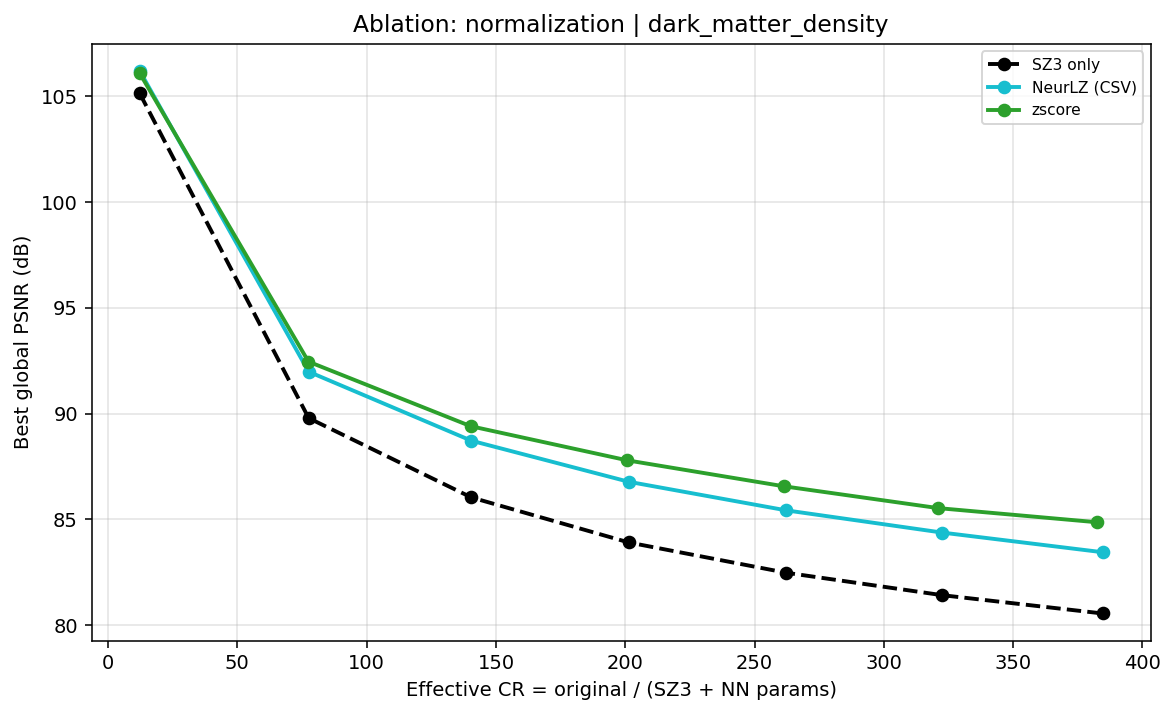

In [6]:
PSNR_MODE = "best"
INCLUDE_AUX_BYTES = False
NEURLZ_DTYPE_BYTES = 4

x_true = np.asarray(Xs[0], np.float32)
original_target_bytes = int(x_true.nbytes)
aux_bytes = 0
if INCLUDE_AUX_BYTES and len(Xs) > 1:
    aux_bytes = int(sum(np.asarray(f, np.float32).nbytes for f in Xs[1:]))

for r in results_compare:
    patch_sz3_bytes(r)


def rows_for_panel(panel: str):
    rows = []
    for tag, rel in REL_SETTINGS:
        Xps_rel, _, b = build_Xps_for_rel(float(rel))
        xp = np.asarray(Xps_rel[0], np.float32)
        sz3_b = float(len(b))
        tot = sz3_b + aux_bytes
        rows.append({
            "label": "SZ3 only",
            "rel_err": float(rel),
            "effective_cr": float(original_target_bytes / tot),
            "psnr": float(psnr_np(x_true, xp)),
            "ls": "--",
            "c": "black",
        })
    for r in results_compare:
        nm = str(r.get("name", ""))
        if "NeurLZ" in nm and TARGET_STEM in nm:
            rel = float(r.get("rel_err", float("nan")))
            if not np.isfinite(rel):
                continue
            sz3_b = float(r["sz3_bytes"])
            nn_b = float(model_param_bytes(r.get("model"), dtype_bytes=NEURLZ_DTYPE_BYTES))
            tot = sz3_b + nn_b + aux_bytes
            rows.append({
                "label": "NeurLZ",
                "rel_err": rel,
                "effective_cr": float(original_target_bytes / tot),
                "psnr": float(get_run_psnr(r, mode=PSNR_MODE)),
                "ls": "-",
                "c": "tab:cyan",
            })
    for r in results_compare:
        if r.get("ablation_panel") != panel:
            continue
        rel = float(r.get("rel_err", float("nan")))
        if not np.isfinite(rel):
            continue
        sz3_b = float(r["sz3_bytes"])
        nn_b = float(model_param_bytes(r.get("model"), dtype_bytes=MODEL_DTYPE_BYTES))
        tot = sz3_b + nn_b + aux_bytes
        tag = str(r.get("ablation_tag", "?"))
        rows.append({
            "label": tag,
            "rel_err": rel,
            "effective_cr": float(original_target_bytes / tot),
            "psnr": float(get_run_psnr(r, mode=PSNR_MODE)),
            "ls": "-",
            "c": None,
        })
    return pd.DataFrame(rows)


def plot_panel(panel: str, title: str):
    df = rows_for_panel(panel)
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["effective_cr", "psnr"])
    best = df.groupby(["label", "rel_err"], as_index=False).agg({"effective_cr": "mean", "psnr": "max"})
    plt.figure(figsize=(8.5, 5.2), dpi=140)
    cmap = plt.get_cmap("tab10")
    fixed_color = {"SZ3 only": "black", "NeurLZ": "tab:cyan"}
    ladder_line_colors = {
        "M0_baseline": "tab:green",
        "M1_plus_freq": "#d62728",
        "M2_plus_freq_split3": "#1f77b4",
    }
    fixed_ls = {"SZ3 only": "--", "NeurLZ": "-"}
    labels_order = []
    for pref in ("SZ3 only", "NeurLZ"):
        if pref in set(best["label"]):
            labels_order.append(pref)
    rest = sorted([l for l in best["label"].unique() if l not in labels_order])
    labels_order += rest
    for i, lab in enumerate(labels_order):
        g = best[best["label"] == lab].sort_values("effective_cr")
        if g.empty:
            continue
        sub = df[df["label"] == lab].iloc[0]
        ls = fixed_ls.get(lab, str(sub["ls"]))
        co = sub["c"]
        if lab in fixed_color:
            c = fixed_color[lab]
        elif lab in ladder_line_colors:
            c = ladder_line_colors[lab]
        elif co is not None and not pd.isna(co):
            c = co
        else:
            c = cmap(i % 10)
        plt.plot(g["effective_cr"], g["psnr"], marker="o", linestyle=ls, color=c, label=lab, linewidth=2)
    plt.xlabel("Effective CR = original / (SZ3 + NN params)")
    plt.ylabel(f"{PSNR_MODE.capitalize()} global PSNR (dB)")
    plt.title(title + f" | {TARGET_STEM}")
    plt.grid(True, alpha=0.35)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_panel("norm", "Ablation: normalization")